In [3]:
import pandas as pd
import numpy as np
import pytz

from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV

In [4]:
df = pd.read_csv('data.csv')
print(df.head())

                   timestamp  price_eur_mwh  demand_forecast_mwh  \
0  2023-12-31 23:00:00+00:00           0.10              4068.18   
1  2024-01-01 00:00:00+00:00           0.01              3892.38   
2  2024-01-01 01:00:00+00:00           0.04              3644.58   
3  2024-01-01 02:00:00+00:00           0.01              3493.50   
4  2024-01-01 03:00:00+00:00           0.01              3454.03   

   solar_forecast_mwh  net_exchange_forecast_mwh  
0                 0.0                    -1089.2  
1                 0.0                     -971.5  
2                 0.0                     -860.7  
3                 0.0                     -733.1  
4                 0.0                     -700.0  


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp                  17544 non-null  object 
 1   price_eur_mwh              17544 non-null  float64
 2   demand_forecast_mwh        17544 non-null  float64
 3   solar_forecast_mwh         17544 non-null  float64
 4   net_exchange_forecast_mwh  17544 non-null  float64
dtypes: float64(4), object(1)
memory usage: 685.4+ KB


**Data prep**

In [6]:
def convert_to_cet(df : pd.DataFrame):
    '''
    Converting from UTC to CET and then deleting zone info for convenience
    '''
    df['timestamp'] = pd.to_datetime(df['timestamp'], yearfirst = True)
    local_timezone = pytz.timezone('Europe/Budapest')
    df['timestamp_CET'] = df['timestamp'].dt.tz_convert(local_timezone)
    df['timestamp_CET'] = df['timestamp_CET'].dt.tz_localize(None)
    df = df.drop('timestamp',axis=1)
    df = df.set_index('timestamp_CET')
    return df

def dst_handling(df : pd.DataFrame):
  '''
  CET has irregularities at DST transitions:
  23-hour days (spring) produce a missing hour that was linearly interpolated;
  25-hour days (autumn) produce a duplicate hour where the second occurrence was discarded.
  '''
  df1=df.groupby([ df.index.date]).size()
  indexes_with_23_hours = df1[df1==23]
  indexes_with_25_hours = df1[df1==25]
  for date in indexes_with_23_hours.index:
    df.loc[pd.Timestamp(date)+pd.Timedelta(hours=2)] = np.nan
  df.sort_index(inplace=True)
  df = df.interpolate(method='time')
  for date in indexes_with_25_hours.index:
    df = df[~df.index.duplicated(keep="first")]
  return df
df = convert_to_cet(df)
df = dst_handling(df)

In [7]:
df.isnull().sum()

,0
price_eur_mwh,0
demand_forecast_mwh,0
solar_forecast_mwh,0
net_exchange_forecast_mwh,0


**FEATURE ENGINEERING**

In [8]:

def demand_minus_solar(df : pd.DataFrame):

  df = df.copy()
  df['demand_minus_solar'] = df['demand_forecast_mwh'] - df['solar_forecast_mwh']

  return df


def cross_intreactions(df,columns = ['demand_forecast_mwh','solar_forecast_mwh','net_exchange_forecast_mwh']):
    df = df.copy()
    for i in range(len(columns)):
        for j in range(i+1,len(columns)):
            df[f'{columns[i]} x {columns[j]}'] = df[columns[i]] * df[columns[j]]
    return df

def calc_ramps(df, columns = ['demand_forecast_mwh','solar_forecast_mwh','net_exchange_forecast_mwh','price_eur_mwh']):
    df = df.copy()

    for col in columns:
        if col == 'price_eur_mwh':
            df[f'{col}_ramp_24_48'] = df[f'{col}_lag_24'] - df[f'{col}_lag_48']
            df[f'{col}_ramp_48_168'] = df[f'{col}_lag_48'] - df[f'{col}_lag_168']
        else:
            df[f'{col}_ramp_curr_24'] = df[col] - df[f'{col}_lag_24']
            df[f'{col}_ramp_curr_168'] = df[col] - df[f'{col}_lag_168']

    return df



def get_calendar_features(df : pd.DataFrame):
  '''
  getting calendar features such as year, month, day, hour, a day of a week, is_weekend flag, and season
  '''
  df = df.copy()
  df['year'] = df.index.year
  df['month'] = df.index.month
  df['day'] = df.index.day
  df['hour'] = df.index.hour
  df['dayofweek'] = df.index.dayofweek
  #df['is_weekend'] = df.index.dayofweek >=5

  def get_season(month):
      if month in [12,1,2]:
          return 0
      elif month in [3,4,5]:
          return 1
      elif month in [6,7,8]:
          return 2
      else:
          return 3
  df['season'] = df['month'].apply(get_season)


  return df

def drop_unused_features(df : pd.DataFrame,cols_to_drop : list =['day','hour','month']):
    '''
    Dropping unnecessary features and NaNs
    '''
    df = df.copy()
    df = df.drop(columns=cols_to_drop)
    df = df.dropna()
    return df


def add_lags(df : pd.DataFrame, columns : list = ['price_eur_mwh'], lags : list = [24,48,168]):
    """
    Adds lag(24h,48h,168h) features to a DataFrame based on the columns provided.
    """
    df_lags = df.copy()
    for col in columns:

        for lag in lags:
            df_lags[f'{col}_lag_{lag}'] = df_lags[col].shift(lag)


    return df_lags

def add_fourier_features(df : pd.DataFrame,column_name : str, period : int, order : int = 4):
    '''
    sine/cosine pairs over the provided cycle. Foe example, monthly cycles. It can help smooth seasonal variation without requiring the model to infer it from calendar dummies.
    '''
    df=df.copy()

    for k in range(1, order + 1):
        df[f'fourier_{period}_sin_order_{k}'] = np.sin(2 * np.pi * k * df[column_name] / period)
        df[f'fourier_{period}_cos_order_{k}'] = np.cos(2 * np.pi * k * df[column_name] / period)
    return df

def add_rolling_stats(df : pd.DataFrame, target_col : str = 'price_eur_mwh'):
    '''
    24h and 168h windows: mean, std, min, max. Same-hour-7d mean and std additionally capture weekday-specific level and volatility.
    Applied to a target column
    '''

    day = df[target_col].resample('D').agg(price_mean_24h = 'mean', price_std_24h = 'std',min_24h = 'min', max_24h = 'max').shift(1)
    day['price_mean_7d'] = df[target_col].resample('D').mean().rolling(7).mean().shift(1)
    day['price_std_7d'] = df[target_col].resample('D').mean().rolling(7).std().shift(1)
    day['price_max_7d'] = df[target_col].resample('D').max().rolling(7).max().shift(1)
    day['price_min_7d'] = df[target_col].resample('D').min().rolling(7).min().shift(1)


    df_rolling_stats = df.copy()
    df_rolling_stats['date'] = df_rolling_stats.index.date
    day.index = day.index.date

    df_rolling_stats= df_rolling_stats.join(day, on='date')
    df_rolling_stats.drop('date',axis=1,inplace=True)
    df_rolling_stats['same_hour_mean_7d'] = df.groupby('hour')[target_col].transform(lambda x: x.shift(1).rolling(7).mean())
    df_rolling_stats['same_hour_std_7d'] = df.groupby('hour')[target_col].transform(lambda x: x.shift(1).rolling(7).std())

    return df_rolling_stats


In [9]:
df = demand_minus_solar(df)
df = get_calendar_features(df)
df = cross_intreactions(df)
df = add_rolling_stats(df, target_col='price_eur_mwh')
df = add_lags(df, columns=['price_eur_mwh','demand_forecast_mwh','solar_forecast_mwh','net_exchange_forecast_mwh','demand_minus_solar'], lags=[24,48,168])
df = calc_ramps(df)
df = add_fourier_features(df,'month', period = 12)
df = drop_unused_features(df,['day','month','hour','year'])


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17376 entries, 2024-01-08 00:00:00 to 2025-12-31 23:00:00
Data columns (total 51 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   price_eur_mwh                                    17376 non-null  float64
 1   demand_forecast_mwh                              17376 non-null  float64
 2   solar_forecast_mwh                               17376 non-null  float64
 3   net_exchange_forecast_mwh                        17376 non-null  float64
 4   demand_minus_solar                               17376 non-null  float64
 5   dayofweek                                        17376 non-null  int32  
 6   season                                           17376 non-null  int64  
 7   demand_forecast_mwh x solar_forecast_mwh         17376 non-null  float64
 8   demand_forecast_mwh x net_exchange_forecast_mwh  17376 non-null  float6

MODELING

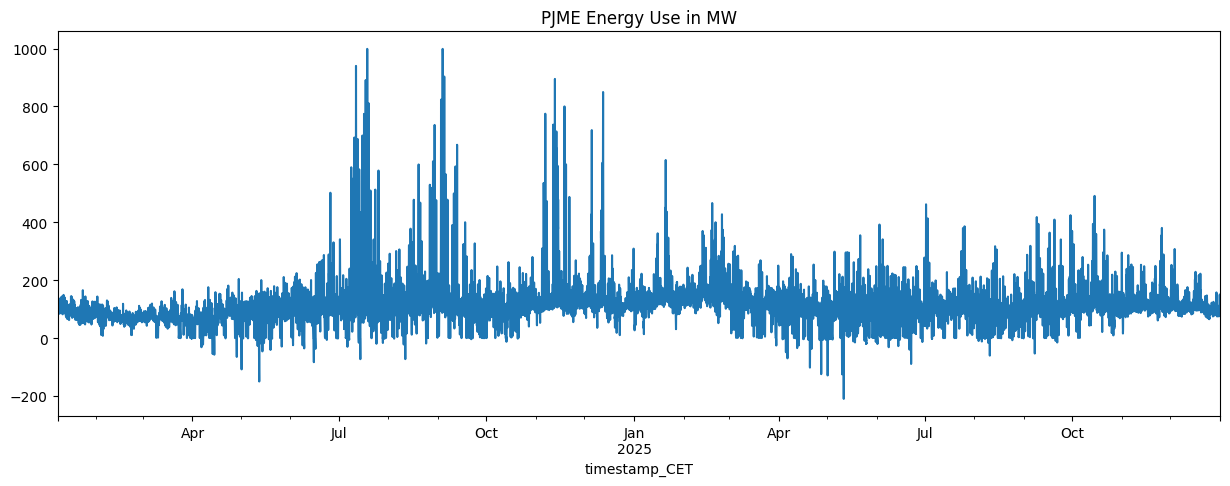

In [11]:
df['price_eur_mwh'].plot(style='-',
        figsize=(15, 5),
        title='PJME Energy Use in MW')
plt.show()

In [12]:
'''fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['price_eur_mwh'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['price_eur_mwh'].plot(ax=axs[fold],
                         label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.show()'''

"fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)\n\nfold = 0\nfor train_idx, val_idx in tss.split(df):\n    train = df.iloc[train_idx]\n    test = df.iloc[val_idx]\n    train['price_eur_mwh'].plot(ax=axs[fold],\n                          label='Training Set',\n                          title=f'Data Train/Test Split Fold {fold}')\n    test['price_eur_mwh'].plot(ax=axs[fold],\n                         label='Test Set')\n    axs[fold].axvline(test.index.min(), color='black', ls='--')\n    fold += 1\nplt.show()"

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17376 entries, 2024-01-08 00:00:00 to 2025-12-31 23:00:00
Data columns (total 51 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   price_eur_mwh                                    17376 non-null  float64
 1   demand_forecast_mwh                              17376 non-null  float64
 2   solar_forecast_mwh                               17376 non-null  float64
 3   net_exchange_forecast_mwh                        17376 non-null  float64
 4   demand_minus_solar                               17376 non-null  float64
 5   dayofweek                                        17376 non-null  int32  
 6   season                                           17376 non-null  int64  
 7   demand_forecast_mwh x solar_forecast_mwh         17376 non-null  float64
 8   demand_forecast_mwh x net_exchange_forecast_mwh  17376 non-null  float6

BASELINE **Seasonal naive** (same hour 7 days prior)

In [14]:
TARGET = 'price_eur_mwh'

y_pred = df['price_eur_mwh_lag_168']
y_true = df[TARGET]

test_predictions = y_pred[-24*45:]
test_true_values = y_true[-24*45:]


mae = mean_absolute_error(test_true_values, test_predictions)
rmse = np.sqrt(mean_squared_error(test_true_values, test_predictions))

test_timestamps = df.index[-24*45:]


In [15]:
print(f'MAE {mae}')
print(f'RMSE {rmse}')

MAE 24.929287037037035
RMSE 41.165113572817496


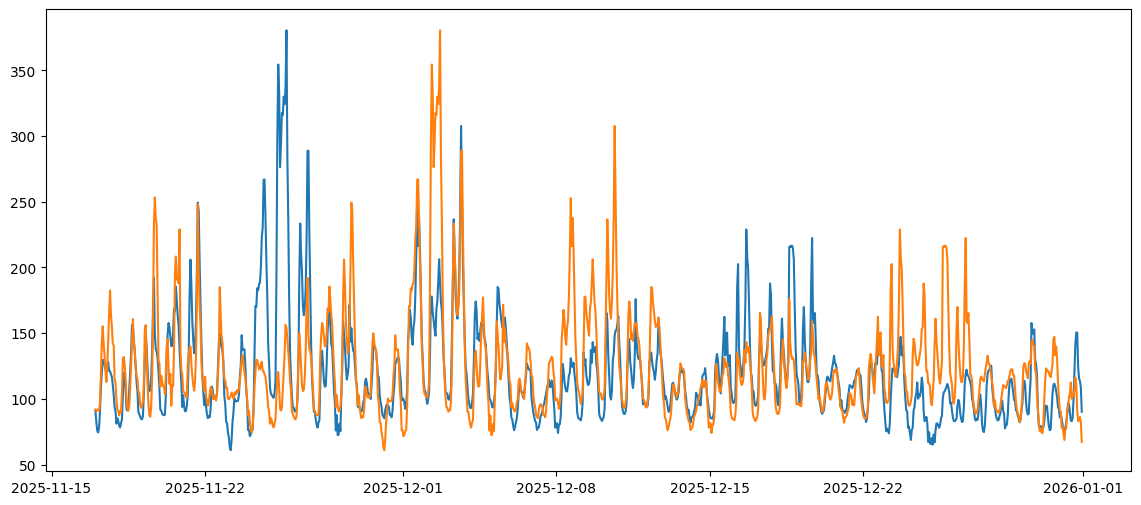

In [16]:
re = pd.DataFrame({
    'time': test_timestamps,
    'actual': test_true_values,
    'predicted': test_predictions
})
re = re.sort_values('time')

# Plot actual vs predicted values
plt.figure(figsize=(14,6))
plt.plot(re['time'], re['actual'], label='Actual')
plt.plot(re['time'], re['predicted'], label='Predicted')


**LightGBM**

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004151 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10117
[LightGBM] [Info] Number of data points in the train set: 15216, number of used features: 50
[LightGBM] [Info] Start training from score 102.751876
                                          Attribute  Importance
19                             price_eur_mwh_lag_24         165
14                                     price_std_7d         145
10                                    price_std_24h         133
13                                    price_mean_7d         126
11                                          min_24h         121
3                                demand_minus_solar         120
17                                same_hour_mean_7d         119

<Axes: xlabel='Importance', ylabel='Attribute'>

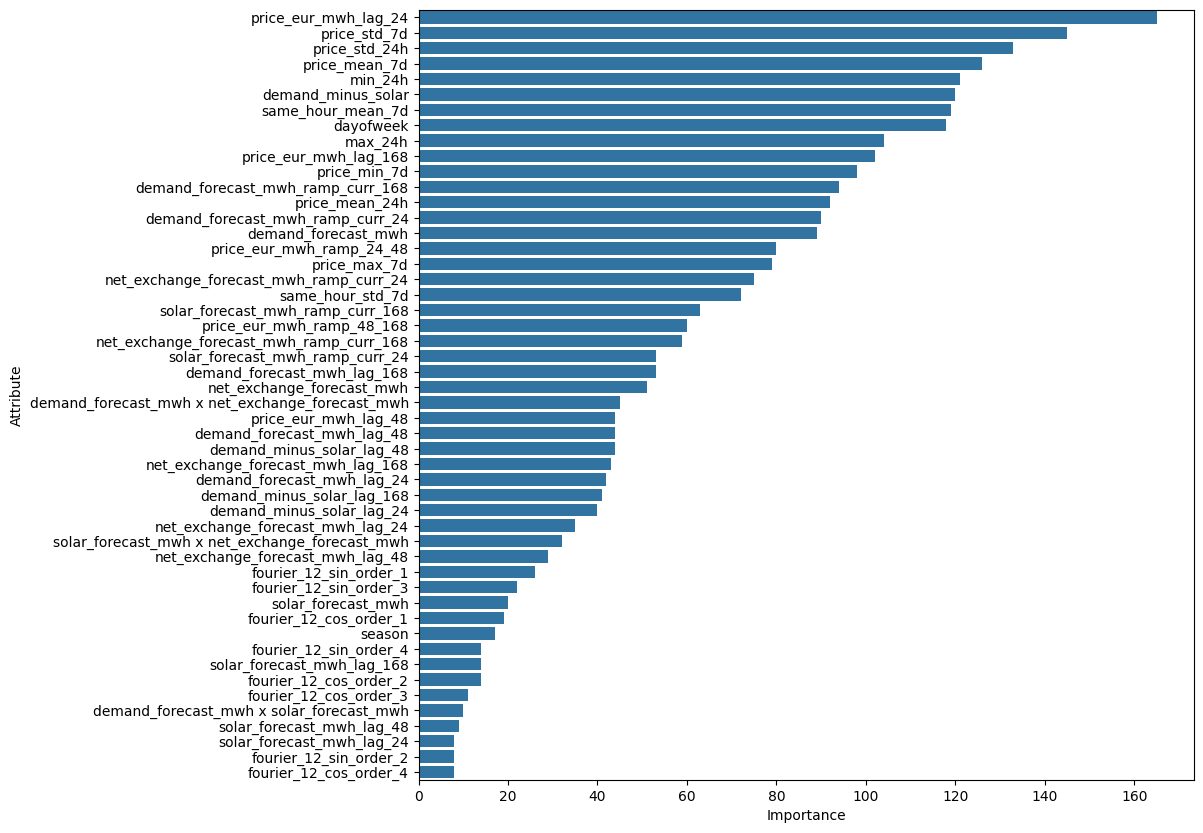

In [17]:
df_train = df[:-24*90]
TARGET = 'price_eur_mwh'

X_train = df_train.drop(columns=[TARGET]) # train+val
y_train = df_train[TARGET] # train+val



reg = lgb.LGBMRegressor(random_state=42)
reg.fit(X_train, y_train)
importances = pd.DataFrame(data={
    'Attribute': X_train.columns,
    'Importance': reg.feature_importances_})
importances = importances.sort_values(by='Importance', ascending=False)
print(importances)
plt.figure(figsize=(10,10))
sns.barplot(x='Importance', y='Attribute', data=importances)



In [18]:
selected_features = importances[importances['Importance'] > 20]['Attribute'].tolist()

In [19]:
df = df[selected_features + [TARGET]]

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17376 entries, 2024-01-08 00:00:00 to 2025-12-31 23:00:00
Data columns (total 39 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   price_eur_mwh_lag_24                             17376 non-null  float64
 1   price_std_7d                                     17376 non-null  float64
 2   price_std_24h                                    17376 non-null  float64
 3   price_mean_7d                                    17376 non-null  float64
 4   min_24h                                          17376 non-null  float64
 5   demand_minus_solar                               17376 non-null  float64
 6   same_hour_mean_7d                                17376 non-null  float64
 7   dayofweek                                        17376 non-null  int32  
 8   max_24h                                          17376 non-null  float6

In [21]:
#Split on train+val and TEST

df_train = df[:-24*45]
TARGET = 'price_eur_mwh'

X_train_full = df_train.drop(columns=[TARGET]) # train+val
y_train_full = df_train[TARGET] # train+val

tss = TimeSeriesSplit(n_splits=45, test_size=24*1)
df_train = df_train.sort_index()


In [ ]:

param_dist = {
    "n_estimators": [500, 1000, 2000],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "reg_alpha": [0.01, 0.1, 0.8]

}

search = RandomizedSearchCV(
    lgb.LGBMRegressor(objective='regression',device_type="gpu"),
    param_distributions=param_dist,
    n_iter=20,
    cv=tss,
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_full, y_train_full)

In [ ]:
search.best_params_

In [ ]:
best_params = search.best_params_
print(best_params)

In [ ]:
'''from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV

df_test = df[-24*45:]
df_train = df[:-24*45]

X_test = df_test.drop(columns=['price_eur_mwh'])
y_test = df_test['price_eur_mwh']

tss = TimeSeriesSplit(n_splits=45, test_size=24)
df_train = df_train.sort_index()

from sklearn.metrics import mean_squared_error,mean_absolute_error
fold = 0
preds = []
scores1 = []
scores2 = []
mae_scores = []

all_preds = []
true_test=[]
timestamp = []
param_dist = {
    "n_estimators": [ 300, 500, 1000,2000],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.7, 0.8, 1.0],
    "reg_alpha": [0.01, 0.1, 1],
    "reg_lambda": [0, 1, 5,10]
}
for train_idx, val_idx in tss.split(df_train):
    train = df_train.iloc[train_idx]
    test = df_train.iloc[val_idx]



    TARGET = 'price_eur_mwh'

    X_train = train.drop(columns=[TARGET])
    y_train = train[TARGET]

    X_val = test.drop(columns=[TARGET])
    y_val = test[TARGET]



    reg = lgb.LGBMRegressor(n_estimators=2000,
                           early_stopping_rounds=50,
                           max_depth=-1,
                           learning_rate=0.01,objective='regression')
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            eval_metric = 'rmse',
            callbacks = [lgb.log_evaluation(period=50)])

    y_pred = reg.predict(X_test_full_scaled)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    mae = mean_absolute_error(y_test, y_pred)
    scores1.append(score)
    scores2.append(mape)
    mae_scores.append(mae)

    all_preds.append(y_pred)
    true_test.append(y_test)
    #timestamp.append(y_test.index)
    '''

In [23]:
#So when we took train+val, we left 45 days for testing, here we go

tss = TimeSeriesSplit(n_splits=45, test_size=24)


test_predictions = []
test_true_values=[]
timestamps = []
for train_idx, test_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[test_idx]



    TARGET = 'price_eur_mwh'

    X_train = train.drop(columns=[TARGET])
    y_train = train[TARGET]

    X_test = test.drop(columns=[TARGET])
    y_test = test[TARGET]



    reg = lgb.LGBMRegressor(learning_rate= 0.01,
             max_depth= 7,
             n_estimators = 1000,
             reg_alpha= 0.8,
             objective='regression',
             random_state=42)
    reg.fit(X_train, y_train)


    y_pred = reg.predict(X_test)

    test_predictions.append(y_pred)
    test_true_values.append(y_test)
    timestamps.append(test.index)




[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001705 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8804
[LightGBM] [Info] Number of data points in the train set: 16296, number of used features: 38
[LightGBM] [Info] Start training from score 103.978759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [24]:
y_all_preds = np.concatenate(test_predictions)
y_true_test=np.concatenate(test_true_values)
test_timestamps = np.concatenate(timestamps)

In [25]:
re = pd.DataFrame({
    'time': test_timestamps,
    'actual': y_true_test,
    'predicted': y_all_preds
})


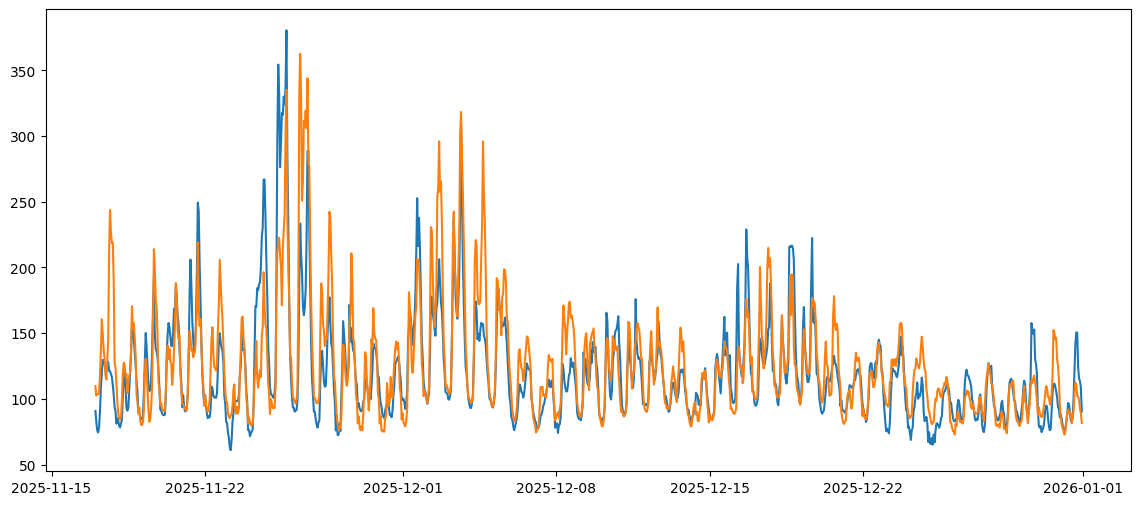

In [26]:
re = re.sort_values('time')

# Plot actual vs predicted values
plt.figure(figsize=(14,6))
plt.plot(re['time'], re['actual'], label='Actual')
plt.plot(re['time'], re['predicted'], label='Predicted')


In [27]:
mean_absolute_error(y_true_test, y_all_preds)

17.55747961302873

In [28]:
rmse = np.sqrt(mean_squared_error(y_true_test, y_all_preds))

In [29]:
rmse

np.float64(27.68850750225725)